# Downloading the Devon Ice Cap airborne gravity survey

Accessed from https://dataverse.tdl.org/dataset.xhtml?persistentId=doi:10.18738/T8/OQWRKP

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

/home/mdtanker/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## load data

Manually download the entire ZIP files from: https://dataverse.tdl.org/dataset.xhtml?persistentId=doi:10.18738/T8/OQWRKP

Unzip it and place it in `docs/data`.

In [3]:
from pathlib import Path

path = Path("data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2").glob("*")
pathfiles = [x for x in path if x.is_file()]
pathfiles

[PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_X103a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_X47a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_X55a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_X63a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_X71a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_X79a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_X87a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_X95a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_Y51a.txt'),
 PosixPath('data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_Y59a.txt'),
 PosixPath('data/do

In [5]:
dfs = []
flights = []
for p in pathfiles:
    df = pd.read_csv(
        p,
        skiprows=58,
        sep=r"\s+",
        header=None,
        names=[
            "year",
            "day_of_year",
            "seconds_of_day",
            "lon",  # wgs 84
            "lat",  # wgs 84
            "gravity_disturbance",  # filtered (2sec box car) mag anom with IGRF13 removed
            "height",  # aircraft elevation WGS84
        ],
    )
    # get flight ID from end of file name
    flight = str(p).split("_")[-1][:-4]
    if flight in flights:
        print(f"Flight {flight} is in multiple files")
    flights.append(flight)
    df["flight_id"] = flight

    dfs.append(df)
data_df = pd.concat(dfs)
data_df

Flight Y83a is in multiple files
Flight Y81a is in multiple files


,year,day_of_year,seconds_of_day,lon,lat,gravity_disturbance,height,flight_id
0,2018,151,27170.3148,-83.985619,75.159637,NaN,NaN,X103a
1,2018,151,27171.3118,-83.985184,75.160332,NaN,NaN,X103a
2,2018,151,27172.3148,-83.984756,75.161034,NaN,NaN,X103a
3,2018,151,27173.3129,-83.984337,75.161720,NaN,NaN,X103a
4,2018,151,27174.3136,-83.983932,75.162422,NaN,NaN,X103a
...,...,...,...,...,...,...,...,...
579,2018,158,17071.2607,-84.796997,75.396751,NaN,NaN,IB95530a
580,2018,158,17072.2638,-84.800056,75.396759,NaN,NaN,IB95530a
581,2018,158,17073.2599,-84.803131,75.396782,NaN,NaN,IB95530a
582,2018,158,17074.2621,-84.806183,75.396812,NaN,NaN,IB95530a


In [6]:
data_df.flight_id.unique()

<ArrowStringArray>
[   'X103a',     'X47a',     'X55a',     'X63a',     'X71a',     'X79a',
     'X87a',     'X95a',     'Y51a',     'Y59a',     'Y67a',     'Y75a',
     'Y83a',     'Y83b',     'X51a',     'X59a',     'X67a',     'X75a',
     'X83a',     'X91a',     'X99a',     'Y47a',     'Y55a',     'Y63a',
     'Y71a',     'Y79a',     'Y87a',     'Y87b',      'Y5a',    'X101a',
     'X57a',     'X65a',     'X69a',     'X72a',     'X73a',     'X77a',
     'X78a',     'X80a',     'X81a',     'X85a',     'X86a',     'X89a',
     'X93a',     'X97a',     'Y47b',     'X33a',     'X37a',     'X41a',
     'X45a',     'X49a',     'X53a',     'X61a',     'Y53a',     'Y61a',
     'Y69a',     'Y73a',     'Y77a',     'Y85a',     'Y81a',     'Y82a',
     'Y90a',     'Y91a',     'X29a',     'X74a',     'X76a',     'X82a',
     'X84a',     'Y49a',     'Y57a',     'Y65a',     'Y89a', 'IB95530a']
Length: 72, dtype: str

In [7]:
# make unique flight number as float for plotting
data_df["flight"] = airbornegeo.unique_line_id(data_df, line_col_name="flight_id")
data_df.flight.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72])

## Reproject

In [8]:
data_df["easting"], data_df["northing"] = airbornegeo.reproject(
    data_df.lon,
    data_df.lat,
    input_crs="EPSG:4326",
    output_crs="EPSG:3413",
)
data_df.head()

,year,day_of_year,seconds_of_day,lon,lat,gravity_disturbance,height,flight_id,flight,easting,northing
0,2018,151,27170.3148,-83.985619,75.159637,NaN,NaN,X103a,1,-1.016856e+06,-1.256358e+06
1,2018,151,27171.3118,-83.985184,75.160332,NaN,NaN,X103a,1,-1.016799e+06,-1.256306e+06
2,2018,151,27172.3148,-83.984756,75.161034,NaN,NaN,X103a,1,-1.016741e+06,-1.256253e+06
3,2018,151,27173.3129,-83.984337,75.161720,NaN,NaN,X103a,1,-1.016684e+06,-1.256202e+06
4,2018,151,27174.3136,-83.983932,75.162422,NaN,NaN,X103a,1,-1.016626e+06,-1.256149e+06


## Plot data

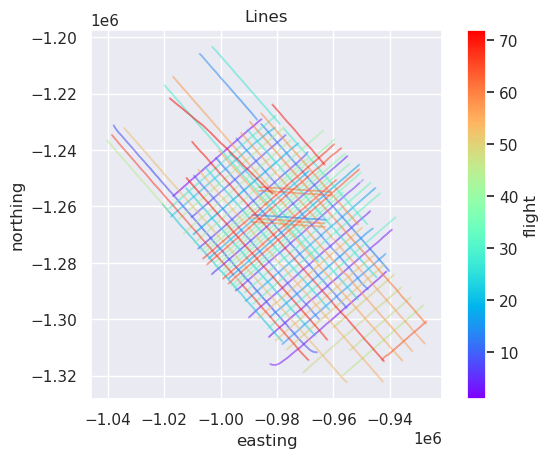

In [9]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="flight",
    s=0.002,
    cmap="rainbow",
    title="Lines",
)
ax.set_aspect("equal")

In [11]:
data_df.head()

,year,day_of_year,seconds_of_day,lon,lat,gravity_disturbance,height,flight_id,flight,easting,northing
0,2018,151,27170.3148,-83.985619,75.159637,NaN,NaN,X103a,1,-1.016856e+06,-1.256358e+06
1,2018,151,27171.3118,-83.985184,75.160332,NaN,NaN,X103a,1,-1.016799e+06,-1.256306e+06
2,2018,151,27172.3148,-83.984756,75.161034,NaN,NaN,X103a,1,-1.016741e+06,-1.256253e+06
3,2018,151,27173.3129,-83.984337,75.161720,NaN,NaN,X103a,1,-1.016684e+06,-1.256202e+06
4,2018,151,27174.3136,-83.983932,75.162422,NaN,NaN,X103a,1,-1.016626e+06,-1.256149e+06


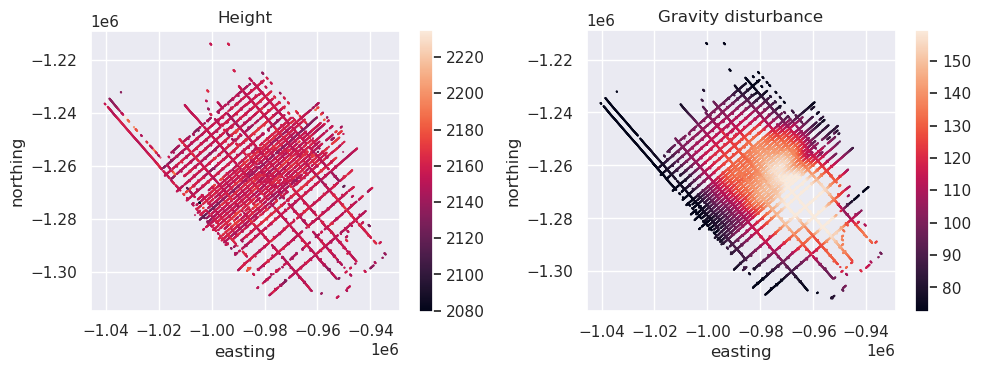

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

df = data_df

ax = df.plot.scatter(
    "easting",
    "northing",
    c="height",
    s=0.2,
    ax=axs[0],
    colorbar=False,
    title="Height",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

cpt_lims = vd.minmax(data_df.gravity_disturbance, min_percentile=5, max_percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="gravity_disturbance",
    s=0.2,
    ax=axs[1],
    colorbar=False,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
    title="Gravity disturbance",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()